In [9]:
"""
导入模块
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
"""
绘图设置，中文支持
"""
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
"""
读取数据
"""
df = pd.read_csv("sales_data.csv")

In [6]:
"""
统计门店数量
"""
store_count = df['Store ID'].nunique()
print("门店总数：", store_count)

门店总数： 5


In [7]:
"""
统计每个门店的总销售量与平均库存水平
"""
store_stats = df.groupby('Store ID').agg({'Units Sold': 'sum', 'Inventory Level': 'mean'}).reset_index()
store_stats  # 查看门店统计信息（Store Statistics）

,Store ID,Units Sold,Inventory Level
0,S001,1318134,277.657368
1,S002,1386126,332.014737
2,S003,1375613,321.993026
3,S004,1308191,293.244211
4,S005,1362812,280.404868


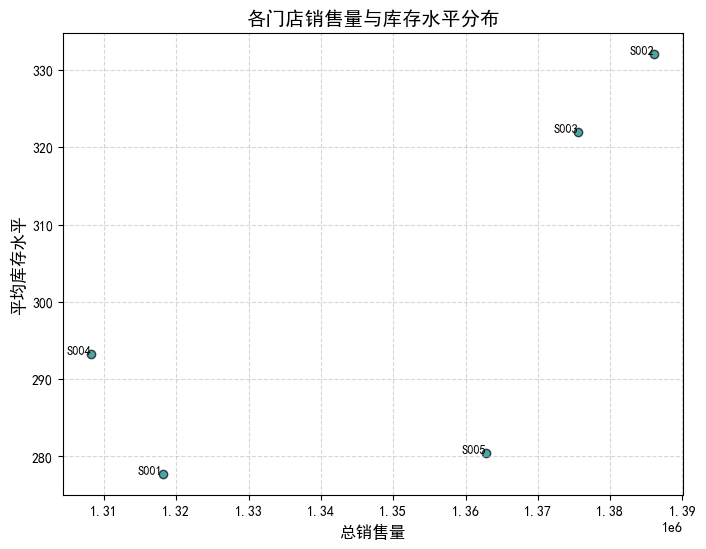

In [4]:
"""
绘图
"""
# 绘制散点图
plt.figure(figsize=(8,6))
plt.scatter(store_stats['Units Sold'], store_stats['Inventory Level'], 
            color='teal', alpha=0.7, edgecolor='k')

# 添加标签
for i, row in store_stats.iterrows():
    plt.text(row['Units Sold'], row['Inventory Level'], row['Store ID'], fontsize=9, ha='right')

# 设置标题
plt.title('各门店销售量与库存水平分布', fontsize=14)
plt.xlabel('总销售量', fontsize=12)
plt.ylabel('平均库存水平', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [11]:
"""
异常点识别
"""
# 计算销量和库存的IQR
Q1_sales = store_stats['Units Sold'].quantile(0.25)
Q3_sales = store_stats['Units Sold'].quantile(0.75)
IQR_sales = Q3_sales - Q1_sales

Q1_inv = store_stats['Inventory Level'].quantile(0.25)
Q3_inv = store_stats['Inventory Level'].quantile(0.75)
IQR_inv = Q3_inv - Q1_inv

# 识别异常门店
store_stats['Sales Anomaly'] = ((store_stats['Units Sold'] < Q1_sales - 1.5*IQR_sales) |
                                (store_stats['Units Sold'] > Q3_sales + 1.5*IQR_sales))

store_stats['Inventory Anomaly'] = ((store_stats['Inventory Level'] < Q1_inv - 1.5*IQR_inv) |
                                    (store_stats['Inventory Level'] > Q3_inv + 1.5*IQR_inv))

# 标记高销量低库存（潜在缺货）和低销量高库存（潜在积压）
store_stats['Potential Issue'] = np.where(
    (store_stats['Units Sold'] > store_stats['Units Sold'].mean()) & 
    (store_stats['Inventory Level'] < store_stats['Inventory Level'].mean()), 'High Sales Low Inventory',
    np.where(
        (store_stats['Units Sold'] < store_stats['Units Sold'].mean()) & 
        (store_stats['Inventory Level'] > store_stats['Inventory Level'].mean()), 'LowSales HighInventory', 'Normal'
    )
)

print(store_stats[['Store ID','Units Sold','Inventory Level','Potential Issue']])

  Store ID  Units Sold  Inventory Level           Potential Issue
0     S001     1318134       277.657368                    Normal
1     S002     1386126       332.014737                    Normal
2     S003     1375613       321.993026                    Normal
3     S004     1308191       293.244211                    Normal
4     S005     1362812       280.404868  High Sales Low Inventory
